# LangGraph Voice Translation Agent

This notebook demonstrates how to convert the voice translation pipeline into a **LangGraph** agent. LangGraph allows us to define the pipeline as a stateful graph of nodes, where each node represents a stage in the translation process (STT, MT, TTS).

## Local Model Management
The pipeline is configured to download and use models from a local `models/` directory within the project root to ensure persistent storage and offline availability.

## 1. Setup and Dependencies

This project uses `uv` for dependency management. Ensure you have the environment synced:
```bash
uv sync
```
Or add dependencies individually:
```bash
uv add langgraph openai-whisper transformers torch edge-tts librosa
```

In [1]:
import os
import sys
from typing import TypedDict, Annotated, Dict
import torch
from langgraph.graph import StateGraph, END

# Add src to path if needed
sys.path.append(os.path.abspath("."))
from pipeline import VoiceTranslationPipeline

## 2. Define Agent State

The state object tracks the information passed between nodes in the graph.

In [2]:
class AgentState(TypedDict):
    audio_path: str
    src_lang: str
    tgt_lang: str
    out_audio_path: str
    original_text: str
    translated_text: str
    metrics: Dict[str, float]

## 3. Implement Workflow Nodes

Each node wraps a stage of the `VoiceTranslationPipeline`. We also include a `cleanup` node to free up memory after processing.

In [3]:
pipeline = VoiceTranslationPipeline()

async def stt_node(state: AgentState):
    import time
    print("--- STT NODE ---")
    start = time.time()
    audio_data = pipeline.load_audio_whisper(state["audio_path"])
    result = pipeline.stt_model.transcribe(audio_data, fp16=(pipeline.device == "cuda"))
    text = result["text"].strip()
    
    return {
        "original_text": text,
        "metrics": {"stt_time": time.time() - start}
    }

async def mt_node(state: AgentState):
    import time
    print("--- MT NODE ---")
    start = time.time()
    translated = pipeline.translate_text(
        state["original_text"], 
        state["src_lang"], 
        state["tgt_lang"]
    )
    
    metrics = state.get("metrics", {})
    metrics["mt_time"] = time.time() - start
    
    return {
        "translated_text": translated,
        "metrics": metrics
    }

async def tts_node(state: AgentState):
    import time
    print("--- TTS NODE ---")
    start = time.time()
    await pipeline.text_to_speech(
        state["translated_text"], 
        state["tgt_lang"], 
        state["out_audio_path"]
    )
    
    metrics = state.get("metrics", {})
    metrics["tts_time"] = time.time() - start
    
    return {
        "metrics": metrics
    }

async def cleanup_node(state: AgentState):
    print("--- CLEANUP NODE ---")
    pipeline.clear_memory()
    return state

Initializing Pipeline on mps
Models directory: /Users/nitinkumar/Work/demo/models


## 4. Assemble the Graph

Now we define the execution flow: `stt -> mt -> tts -> cleanup`.

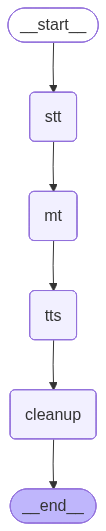

In [5]:
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("stt", stt_node)
workflow.add_node("mt", mt_node)
workflow.add_node("tts", tts_node)
workflow.add_node("cleanup", cleanup_node)

# Define edges
workflow.set_entry_point("stt")
workflow.add_edge("stt", "mt")
workflow.add_edge("mt", "tts")
workflow.add_edge("tts", "cleanup")
workflow.add_edge("cleanup", END)

# Compile graph
app = workflow.compile()
app

## 5. Execution Example

Initialize the state and invoke the graph.

In [6]:
import asyncio

async def run_agent():
    # Configuration
    base_dir = os.path.dirname(os.getcwd())
    audio_input = os.path.join(base_dir, "inputs", "input.wav")
    output_audio = os.path.join(base_dir, "outputs", "output.wav")
    os.makedirs(os.path.dirname(output_audio), exist_ok=True)

    if not os.path.exists(audio_input):
        print(f"Audio input not found: {audio_input}")
        return

    initial_state = {
        "audio_path": audio_input,
        "src_lang": "en",
        "tgt_lang": "es",
        "out_audio_path": output_audio,
        "original_text": "",
        "translated_text": "",
        "metrics": {}
    }

    print("Running LangGraph Voice Agent...")
    final_state = await app.ainvoke(initial_state)
    
    print("\n--- FINAL RESULTS ---")
    print(f"Original: {final_state['original_text']}")
    print(f"Translated: {final_state['translated_text']}")
    print("\nMetrics:")
    for k, v in final_state['metrics'].items():
        print(f" - {k}: {v:.3f}s")

if __name__ == "__main__":
    # Note: In a notebook, use await directly or asyncio.gather if needed
    await run_agent()

Running LangGraph Voice Agent...
--- STT NODE ---
--- MT NODE ---
Loading MT model: Helsinki-NLP/opus-mt-en-es


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

--- TTS NODE ---


model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

--- CLEANUP NODE ---
Clearing models from memory...
Memory cleanup complete.

--- FINAL RESULTS ---
Original: I was glued to the screen as Jasper at Boom reclaimed 415ths, dismantling NZ for 159, and sealing India's third title by 96 runs. The tension peaked with James Nesham's quick wickets, but Chivom Dubes late surge of 26 times off eight balls clinched it analytically. Boomers' hattrick attempt and strike rate control made it a masterclass in death bowling pressure.
Translated: Me pegaron a la pantalla mientras Jasper recuperaba 415ths, desmontando NZ por 159, y sellando el tercer título de India por 96 carreras. La tensión alcanzó su punto máximo con los rápidos wickets de James Nesham, pero Chivom Dubes se a

Metrics:
 - stt_time: 2.176s
 - mt_time: 16.274s
 - tts_time: 1.263s
